In [107]:
import json
import networkx as nx
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from networkx.readwrite import json_graph
from pathlib import Path
import os
import sys
sys.path.insert(0, os.path.abspath('../../../'))
from pipeline.metrics import moran, gini, frey, dissimilarity, assortativity, property_sum, half_edge
from pipeline.metrics import make_adj_weights
import matplotlib.pyplot as plt


In [108]:
graphs_path = Path("../data/cluster_graphs_buffers")

In [109]:
rows = []

for year in [1980, 1990, 2000, 2010, 2020]:
    for city in ["1714000", "4260000"]:
        for radius in range(11):
            cluster1_file = graphs_path / f"{city}_{year}_cluster_1_buffer{radius}.json"
            g_cluster1 = nx.adjacency_graph(json.load(open(cluster1_file)))
            for node in g_cluster1.nodes:
                g_cluster1.nodes[node]["white_plus_black"] = g_cluster1.nodes[node]["WHITE"] + g_cluster1.nodes[node]["BLACK"]
            rows.append({"area_code": city, 
                         "year": year, 
                         "cluster": f"1_{city}", 
                         "buffer": radius, 
                         "num_nodes": g_cluster1.number_of_nodes(), 
                         "num_edges": g_cluster1.number_of_edges(), 
                         "moran": moran(g_cluster1, "BLACK", "white_plus_black")["moran_P"],
                         "dissimilarity": dissimilarity(g_cluster1, "BLACK", "WHITE", 1),
                         "half_edge": half_edge(g_cluster1, "BLACK", "WHITE", 1)
                         })
            cluster2_file = graphs_path / f"{city}_{year}_cluster_2_buffer{radius}.json"
            g_cluster2 = nx.adjacency_graph(json.load(open(cluster2_file)))
            for node in g_cluster2.nodes:
                            g_cluster2.nodes[node]["white_plus_black"] = g_cluster2.nodes[node]["WHITE"] + g_cluster2.nodes[node]["BLACK"]
            rows.append({"area_code": city, 
                         "year": year, 
                         "cluster": f"2_{city}", 
                         "buffer": radius, 
                         "num_nodes": g_cluster2.number_of_nodes(), 
                         "num_edges": g_cluster2.number_of_edges(), 
                         "moran": moran(g_cluster2, "BLACK", "white_plus_black")["moran_P"],
                         "dissimilarity": dissimilarity(g_cluster2, "BLACK", "WHITE", 1),
                         "half_edge": half_edge(g_cluster2, "BLACK", "WHITE", 1)
                         })

df = pd.DataFrame(rows)

/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_98587/2888012328.py:7: ResourceWarning: unclosed file <_io.TextIOWrapper name='../data/cluster_graphs_buffers/1714000_1980_cluster_1_buffer0.json' mode='r' encoding='UTF-8'>
  g_cluster1 = nx.adjacency_graph(json.load(open(cluster1_file)))
/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_98587/2888012328.py:21: ResourceWarning: unclosed file <_io.TextIOWrapper name='../data/cluster_graphs_buffers/1714000_1980_cluster_2_buffer0.json' mode='r' encoding='UTF-8'>
  g_cluster2 = nx.adjacency_graph(json.load(open(cluster2_file)))
/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_98587/2888012328.py:7: ResourceWarning: unclosed file <_io.TextIOWrapper name='../data/cluster_graphs_buffers/1714000_1980_cluster_1_buffer1.json' mode='r' encoding='UTF-8'>
  g_cluster1 = nx.adjacency_graph(json.load(open(cluster1_file)))
/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_98587/2888012328.py:21: ResourceWarning: un

In [110]:
city_names = {
    "1714000": "Chicago",
    "4260000": "Philadelphia"}
df["area_code"] = df["area_code"].map(city_names)

In [111]:
cluster_names = {
    "1_1714000": "South Side",
    "2_1714000": "Austin",
    "1_4260000": "Chester",
    "2_4260000": "Germantown"}
df["cluster"] = df["cluster"].map(cluster_names)

In [112]:
scores_df = pd.read_csv('../../../outputs/tracts_in_max_city/white_black.csv')
scores_df['city_code'] = scores_df['filename'].str.extract(r'tracts_in_max_city_(\d{7})_')
scores_df['year'] = scores_df['filename'].str.extract(r'tracts_in_max_city_\d{7}_(\d{4})_').astype(int)

CITY_CODES = {'Chicago': '1714000', 'Philadelphia': '4260000'}

global_scores = {}
for city, code in CITY_CODES.items():
    global_scores[city] = (
        scores_df[scores_df['city_code'] == code]
        .set_index('year')
        .sort_index()
    )
metric_renames = {"half_edge_1": "half_edge",
                  "moran_P": "moran",
                  "dissimilarity_1": "dissimilarity"}

df_philly = global_scores['Philadelphia'].rename(columns=metric_renames)
df_chi = global_scores['Chicago'].rename(columns=metric_renames)



In [113]:
def metric_v_buffer(df, metric, city, cluster):
    fig, ax = plt.subplots(figsize=(7, 5))
    cmap = plt.colormaps["Blues"]
    colors = [cmap(0.25 + 0.65 * i / 10) for i in range(11)]

    cluster_df = df[(df["area_code"] == city) & (df["cluster"] == cluster)]
    for i in range(11):
        buffer_df = cluster_df[cluster_df["buffer"] == i]
        ax.plot(buffer_df["year"], buffer_df[metric], color=colors[i], linewidth=1.8,
            solid_capstyle="round", label=str(i))
        
    if city == "Philadelphia":
        ax.plot(df_philly.index, df_philly[metric], color="red", linewidth=1.8,
            solid_capstyle="round", label="city-wide")
    else:
        ax.plot(df_chi.index, df_chi[metric], color="red", linewidth=1.8,
            solid_capstyle="round", label="city-wide")
    
    ax.set_xticks([1980, 1990, 2000, 2010, 2020])
    ax.set_xlabel("Year")
    ax.set_ylabel(metric)
    ax.xaxis.set_tick_params(length=0)
    ax.grid(axis="y", color="#ebebeb", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#d0d0d0")
    ax.legend(title="Buffer Radius", bbox_to_anchor=(1.02, 1), loc="upper left",
            fontsize=8, frameon=False)
    ax.set_title(f"{metric} as a Function of Buffer Radius for {cluster} in {city}, 1980-2020")
    plt.tight_layout()
    fig.savefig(f"../figures/{metric}_by_buffer_in_{cluster}_in_{city}.png", dpi=150, bbox_inches="tight")
    plt.show()


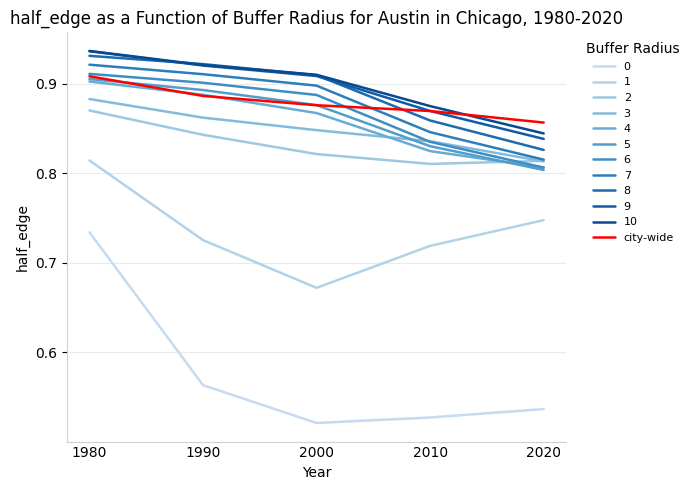

In [125]:
metric_v_buffer(df, "half_edge", "Chicago", "Austin")